# Classical and Relativistic Brachistochrone (Simplified Model)

## Introduction
The **classical brachistochrone problem** asks for the curve connecting two points in a uniform gravitational field that gives the shortest descent time for a frictionless particle.

With speed from energy conservation,
$$
v(y)=\sqrt{2 g y},
$$
the travel-time functional is
$$
T[y] = \int \frac{\sqrt{1+y'^2}}{\sqrt{2 g y}}\,dx.
$$
Applying the Euler-Lagrange equation gives a **cycloid** as the minimizing curve.

This notebook extends the same variational structure to a simplified relativistic model by replacing the classical speed-height relation with a special-relativistic one in a uniform gravitational potential approximation.

### Scope and limitations
- Uniform gravity only.
- Special-relativistic kinetic energy only.
- No drag, thrust, mass loss, control system, atmospheric effects, or general relativity.
- This is a clean mathematical analogue, not a full rocket engineering model.


## Notebook outline
1. Set parameters and helper functions.
2. Build and compare classical candidate curves (line, parabola, cycloid).
3. Define a simplified relativistic speed law and verify low-speed consistency.
4. Generate relativistic trajectories using
   $$
\frac{dx}{dy} = \frac{v(y)}{\sqrt{k^2-v(y)^2}}
$$
   and tune/scan $k$ to hit the endpoint.
5. Compare geometry, speed-height relations, and travel times.
6. Compare classical vs relativistic kinetic-energy scaling.
7. Summarize poster-ready conclusions.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq

# Simple, publication-friendly plotting defaults (no seaborn)
plt.rcParams.update({
    "figure.figsize": (7.0, 4.6),
    "figure.dpi": 130,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "lines.linewidth": 2.2,
})


## 1) Parameters and numerical helpers
We choose a default endpoint pair
$$
A=(0,0),\qquad B=(x_B,y_B),\quad y>0\text{ downward},
$$
with moderate geometric scale for plotting.

`c_physical` is the true speed of light; additional smaller $c_{\mathrm{eff}}$ values are introduced later as **effective regimes** to make relativistic geometric changes visible in a poster-scale figure.


In [2]:
# Physical constants
G = 9.81  # m/s^2
C_PHYSICAL = 299_792_458.0  # m/s

# Endpoint coordinates: start A=(0,0), end B=(X_END, Y_END), y positive downward
X_END = 2.0  # m
Y_END = 1.0  # m

# Numerical resolution
N_PATH = 1200
EPS = 1e-12


def classical_speed(y, g=G):
    """v(y)=sqrt(2 g y), with y>=0."""
    y_safe = np.maximum(y, 0.0)
    return np.sqrt(2.0 * g * y_safe)


def relativistic_gamma(y, g=G, c=C_PHYSICAL):
    """gamma(y)=1+g y / c^2 from (gamma-1)mc^2 = m g y."""
    return 1.0 + g * np.maximum(y, 0.0) / (c ** 2)


def relativistic_speed(y, g=G, c=C_PHYSICAL):
    """Numerically stable v(y) from gamma=1+u with u=g y / c^2."""
    y_safe = np.maximum(y, 0.0)
    u = g * y_safe / (c ** 2)
    # Equivalent to c*sqrt(1 - 1/(1+u)^2), but avoids catastrophic cancellation.
    return c * np.sqrt(u * (2.0 + u)) / (1.0 + u)


def path_time_from_xy(x, y, speed_func):
    """Numerical time integral T = integral ds / v(y) along a sampled path."""
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx * dx + dy * dy)
    y_mid = 0.5 * (y[:-1] + y[1:])
    v_mid = speed_func(y_mid)
    v_mid = np.maximum(v_mid, EPS)
    return np.sum(ds / v_mid)


def path_length(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    return np.sum(np.sqrt(dx * dx + dy * dy))


## 2) Classical model
For a curve $y(x)$,
$$
T[y] = \int_0^{x_B} \frac{\sqrt{1+y'^2}}{\sqrt{2 g y}}\,dx.
$$
The minimizing curve is a cycloid with parametric form
$$
x(\theta)=a(\theta-\sin\theta),\qquad y(\theta)=a(1-\cos\theta),
$$
where $a$ and terminal parameter $\theta_B$ are fixed by the endpoint $(x_B,y_B)$.


In [3]:
def solve_cycloid_params(x_end=X_END, y_end=Y_END):
    """Solve for theta_B and a so cycloid passes through (x_end, y_end)."""
    ratio = y_end / x_end

    def f(theta):
        return (1.0 - np.cos(theta)) / (theta - np.sin(theta)) - ratio

    # Standard brachistochrone branch has theta_B in (0, 2*pi)
    theta_b = brentq(f, 1e-6, 2.0 * np.pi - 1e-6)
    a = y_end / (1.0 - np.cos(theta_b))
    return a, theta_b


def cycloid_path(x_end=X_END, y_end=Y_END, n=N_PATH):
    a, theta_b = solve_cycloid_params(x_end=x_end, y_end=y_end)
    theta = np.linspace(0.0, theta_b, n)
    x = a * (theta - np.sin(theta))
    y = a * (1.0 - np.cos(theta))
    return x, y, a, theta_b


# Candidate classical paths between A and B
x_ref = np.linspace(0.0, X_END, N_PATH)
y_line = Y_END * (x_ref / X_END)
y_parabola = Y_END * (x_ref / X_END) ** 2
x_cyc, y_cyc, a_cyc, theta_b_cyc = cycloid_path()

print(f"Cycloid parameter a = {a_cyc:.4f} m, theta_B = {theta_b_cyc:.4f} rad")


Cycloid parameter a = 0.5172 m, theta_B = 3.5084 rad


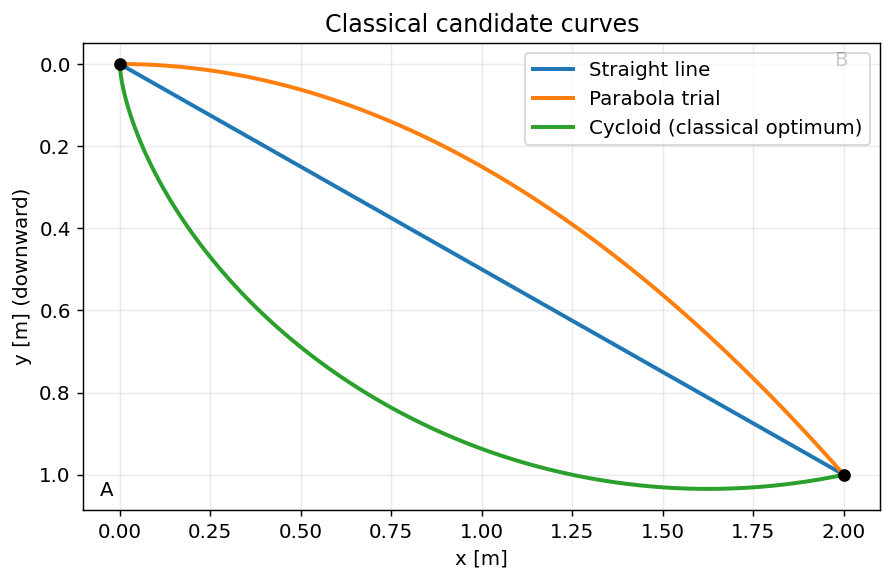

In [4]:
fig, ax = plt.subplots()
ax.plot(x_ref, y_line, label="Straight line")
ax.plot(x_ref, y_parabola, label="Parabola trial")
ax.plot(x_cyc, y_cyc, label="Cycloid (classical optimum)")
ax.scatter([0, X_END], [0, Y_END], color="black", zorder=5)
ax.text(0.02, 0.03, "A", transform=ax.transAxes)
ax.text(0.96, 0.95, "B", transform=ax.transAxes, ha="right")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m] (downward)")
ax.set_title("Classical candidate curves")
ax.legend(frameon=True)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [5]:
# Travel times under classical speed law v=sqrt(2 g y)
classical_rows = []
for name, x_path, y_path in [
    ("Straight line", x_ref, y_line),
    ("Parabola trial", x_ref, y_parabola),
    ("Cycloid", x_cyc, y_cyc),
]:
    t_val = path_time_from_xy(x_path, y_path, lambda y: classical_speed(y, g=G))
    L_val = path_length(x_path, y_path)
    classical_rows.append({
        "Path": name,
        "Travel time [s]": t_val,
        "Path length [m]": L_val,
    })

classical_df = pd.DataFrame(classical_rows).sort_values("Travel time [s]")
classical_df


,Path,Travel time [s],Path length [m]
2,Cycloid,0.805292,2.446070
0,Straight line,1.000819,2.236068
1,Parabola trial,3.903096,2.295587


## 3) Simplified relativistic model
We use
$$
(\gamma-1)mc^2 = m g y
\quad\Rightarrow\quad
\gamma(y)=1+\frac{g y}{c^2},
$$
so
$$
v(y) = c\sqrt{1-\frac{1}{(1+g y/c^2)^2}}.
$$
Then
$$
T[y]=\int \frac{\sqrt{1+y'^2}}{v(y)}\,dx.
$$
The variational structure is similar to the classical case (the integrand still depends on $y$ and $y'$); the key change is the speed-height law.

A first integral gives
$$
\frac{dx}{dy} = \frac{v(y)}{\sqrt{k^2-v(y)^2}},
$$
with constant $k$ chosen so the path ends at $(x_B,y_B)$.


In [6]:
# Low-speed limit sanity check: v_rel ~ sqrt(2 g y) when g y << c^2
y_test = np.linspace(0.0, Y_END, 400)
v_class = classical_speed(y_test, g=G)
v_rel_physical = relativistic_speed(y_test, g=G, c=C_PHYSICAL)

# Ignore y=0 point in relative error to avoid division by zero
mask = y_test > 1e-9
rel_err = np.max(np.abs(v_rel_physical[mask] - v_class[mask]) / np.maximum(v_class[mask], EPS))

print(f"Max relative speed error over y in [0, {Y_END} m] with physical c: {rel_err:.3e}")
print("This confirms the classical limit for ordinary laboratory scales.")


Max relative speed error over y in [0, 1.0 m] with physical c: 2.108e-16
This confirms the classical limit for ordinary laboratory scales.


In [7]:
def x_end_from_k(k, y_end=Y_END, g=G, c=C_PHYSICAL, n=N_PATH):
    """Compute endpoint x(y_end) from dx/dy = v/sqrt(k^2-v^2)."""
    y = np.linspace(0.0, y_end, n)
    v = relativistic_speed(y, g=g, c=c)
    denom_sq = np.maximum(k * k - v * v, EPS)
    integrand = v / np.sqrt(denom_sq)
    x = cumulative_trapezoid(integrand, y, initial=0.0)
    return x[-1]


def solve_k_for_endpoint(x_target=X_END, y_end=Y_END, g=G, c=C_PHYSICAL):
    """Find k such that x(y_end)=x_target using bracketing + Brent root solve."""
    v_max = relativistic_speed(np.array([y_end]), g=g, c=c)[0]
    k_low = v_max * (1.0 + 1e-7)
    k_high = v_max * 1.2 + 1e-12

    f_low = x_end_from_k(k_low, y_end=y_end, g=g, c=c) - x_target
    f_high = x_end_from_k(k_high, y_end=y_end, g=g, c=c) - x_target

    # Increase k_high until x_end(k_high) < x_target (x_end decreases with k)
    it = 0
    while f_high > 0.0 and it < 80:
        k_high *= 1.8
        f_high = x_end_from_k(k_high, y_end=y_end, g=g, c=c) - x_target
        it += 1

    if not (f_low > 0.0 and f_high < 0.0):
        raise RuntimeError("Could not bracket k for the chosen endpoint and parameters.")

    root_fun = lambda kval: x_end_from_k(kval, y_end=y_end, g=g, c=c) - x_target
    return brentq(root_fun, k_low, k_high, xtol=1e-12, rtol=1e-10)


def relativistic_path_from_c(c_eff, x_target=X_END, y_end=Y_END, g=G, n=N_PATH):
    """Return trajectory x(y), y, and fitted k for given effective c."""
    y = np.linspace(0.0, y_end, n)
    k = solve_k_for_endpoint(x_target=x_target, y_end=y_end, g=g, c=c_eff)
    v = relativistic_speed(y, g=g, c=c_eff)
    denom_sq = np.maximum(k * k - v * v, EPS)
    dx_dy = v / np.sqrt(denom_sq)
    x = cumulative_trapezoid(dx_dy, y, initial=0.0)
    return x, y, k


### Tuning/scanning $k$
For fixed $c$, different $k$ values generate different trajectory families. We tune $k$ so that the integrated curve lands exactly at the chosen endpoint $(x_B,y_B)$.


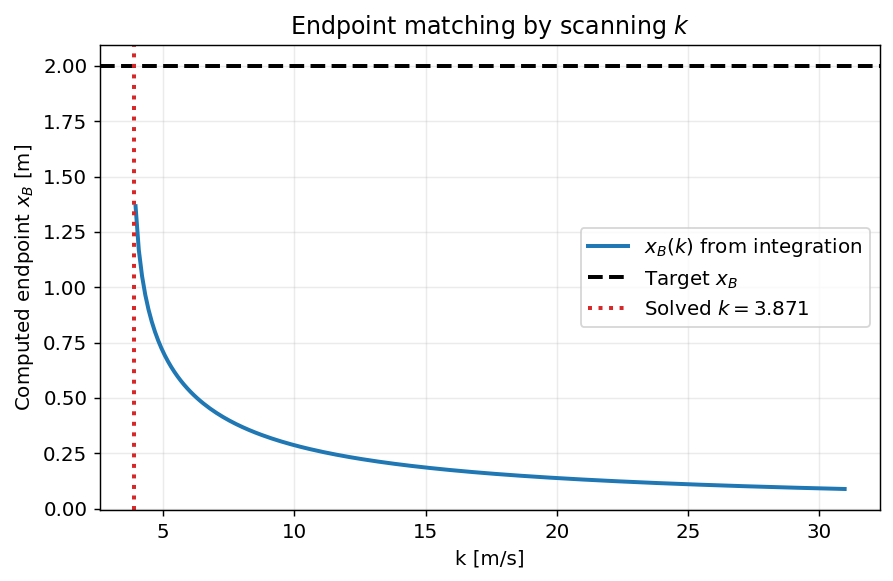

In [8]:
# Demonstrate x_end(k) monotonic trend for one effective relativistic regime
c_scan_demo = 7.0  # m/s (effective; chosen for visible relativistic deviation)
vmax_demo = relativistic_speed(np.array([Y_END]), c=c_scan_demo)[0]
k_grid = np.linspace(vmax_demo * 1.02, vmax_demo * 8.0, 220)
x_grid = np.array([x_end_from_k(k, c=c_scan_demo) for k in k_grid])

k_star_demo = solve_k_for_endpoint(c=c_scan_demo)

fig, ax = plt.subplots()
ax.plot(k_grid, x_grid, label=r"$x_B(k)$ from integration")
ax.axhline(X_END, color="black", linestyle="--", label="Target $x_B$")
ax.axvline(k_star_demo, color="tab:red", linestyle=":", label=fr"Solved $k={k_star_demo:.3f}$")
ax.set_xlabel("k [m/s]")
ax.set_ylabel(r"Computed endpoint $x_B$ [m]")
ax.set_title(r"Endpoint matching by scanning $k$")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## 4) Relativistic regimes and trajectory comparison
Because $g y / c^2\ll 1$ for lab-scale $y$ with physical $c$, geometric differences are tiny in everyday units. So we include:
- one **physical** case (`c = 2.998e8 m/s`), and
- several **effective** $c_{\mathrm{eff}}$ values (arbitrary toy scales) to visualize how increasing relativistic influence changes the optimal shape.

This is equivalent to exploring larger values of the dimensionless ratio $\epsilon = g y_B / c^2$.


In [9]:
# Relativistic regime list: one physical + toy effective values for visualization
regimes = [
    ("Physical c", C_PHYSICAL),
    ("Effective c = 15 m/s", 15.0),
    ("Effective c = 9 m/s", 9.0),
    ("Effective c = 6.5 m/s", 6.5),
]

rel_paths = {}
rel_rows = []

for label, c_eff in regimes:
    x_rel, y_rel, k_rel = relativistic_path_from_c(c_eff)
    t_rel = path_time_from_xy(x_rel, y_rel, lambda yy, c0=c_eff: relativistic_speed(yy, g=G, c=c0))
    L_rel = path_length(x_rel, y_rel)
    v_max = relativistic_speed(np.array([Y_END]), g=G, c=c_eff)[0]
    eps = G * Y_END / (c_eff ** 2)

    rel_paths[label] = {"x": x_rel, "y": y_rel, "k": k_rel, "c": c_eff}
    rel_rows.append({
        "Regime": label,
        "c used [m/s]": c_eff,
        "epsilon = g*yB/c^2": eps,
        "k [m/s]": k_rel,
        "Travel time [s]": t_rel,
        "Path length [m]": L_rel,
        "v(yB) [m/s]": v_max,
    })

rel_df = pd.DataFrame(rel_rows)
rel_df


,Regime,c used [m/s],epsilon = g*yB/c^2,k [m/s],Travel time [s],Path length [m],v(yB) [m/s]
0,Physical c,299792458.0,1.091510e-16,4.429449,0.802225,2.429200,4.429447
1,Effective c = 15 m/s,15.0,4.360000e-02,4.290408,0.816835,2.421617,4.290406
2,Effective c = 9 m/s,9.0,1.211111e-01,4.068815,0.842089,2.408971,4.068811
3,Effective c = 6.5 m/s,6.5,2.321893e-01,3.797724,0.876813,2.392480,3.797717


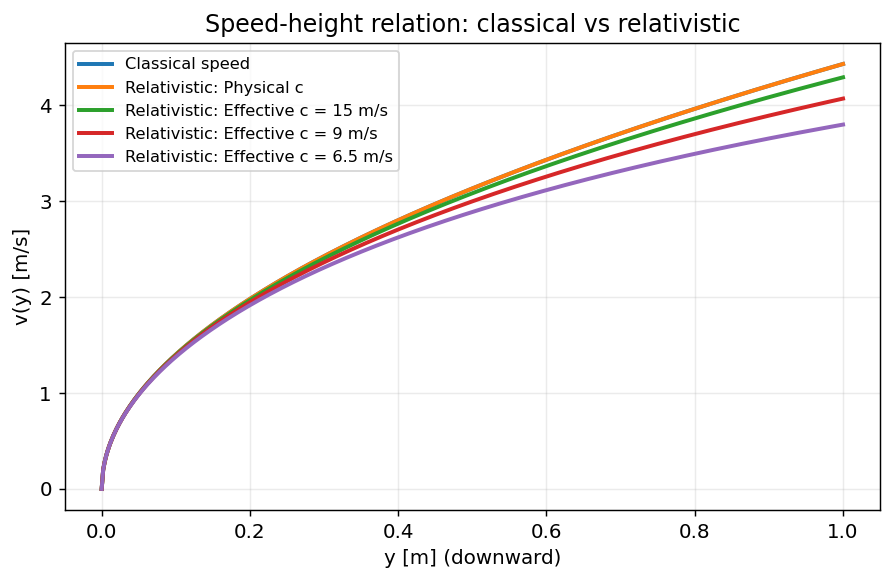

In [10]:
# Speed-height comparison
y_plot = np.linspace(0.0, Y_END, 500)

fig, ax = plt.subplots()
ax.plot(y_plot, classical_speed(y_plot), label="Classical speed")
for label, c_eff in regimes:
    ax.plot(y_plot, relativistic_speed(y_plot, c=c_eff), label=f"Relativistic: {label}")

ax.set_xlabel("y [m] (downward)")
ax.set_ylabel("v(y) [m/s]")
ax.set_title("Speed-height relation: classical vs relativistic")
ax.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()


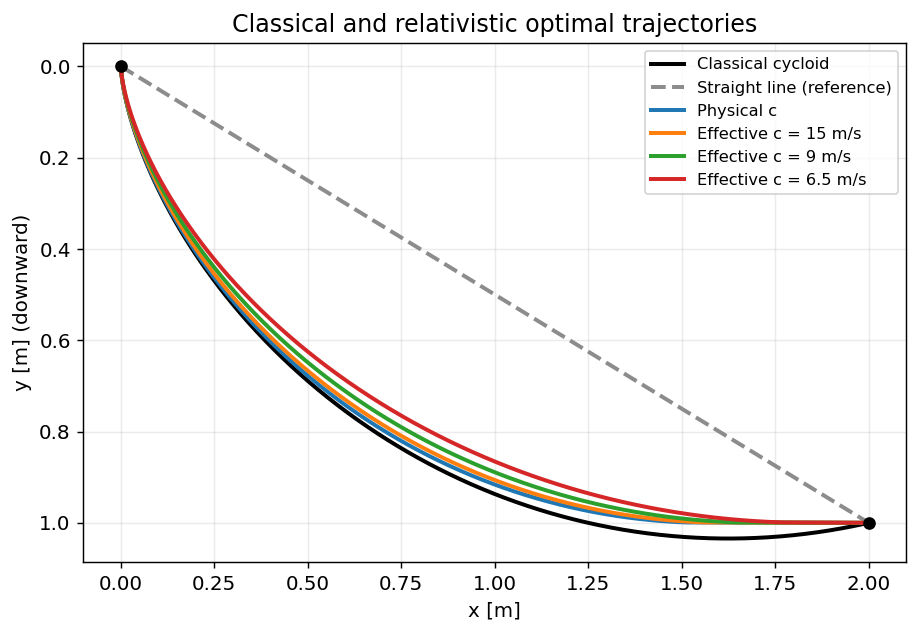

In [11]:
# Trajectory comparison: classical cycloid + relativistic optimized paths
fig, ax = plt.subplots(figsize=(7.2, 5.0))

ax.plot(x_cyc, y_cyc, color="black", label="Classical cycloid")
ax.plot(x_ref, y_line, color="0.55", linestyle="--", label="Straight line (reference)")

for label, data in rel_paths.items():
    ax.plot(data["x"], data["y"], label=label)

ax.scatter([0, X_END], [0, Y_END], color="black", zorder=5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m] (downward)")
ax.set_title("Classical and relativistic optimal trajectories")
ax.legend(frameon=True, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [12]:
# Compact summary table (classical best + relativistic regimes)
classical_best_time = float(classical_df.loc[classical_df["Path"] == "Cycloid", "Travel time [s]"].iloc[0])
classical_best_length = float(classical_df.loc[classical_df["Path"] == "Cycloid", "Path length [m]"].iloc[0])

summary_rows = [{
    "Model": "Classical cycloid",
    "c used [m/s]": np.inf,
    "epsilon = g*yB/c^2": 0.0,
    "k [m/s]": np.nan,
    "Travel time [s]": classical_best_time,
    "Path length [m]": classical_best_length,
    "v(yB) [m/s]": classical_speed(np.array([Y_END]))[0],
}]

for _, row in rel_df.iterrows():
    summary_rows.append({
        "Model": row["Regime"],
        "c used [m/s]": row["c used [m/s]"],
        "epsilon = g*yB/c^2": row["epsilon = g*yB/c^2"],
        "k [m/s]": row["k [m/s]"],
        "Travel time [s]": row["Travel time [s]"],
        "Path length [m]": row["Path length [m]"],
        "v(yB) [m/s]": row["v(yB) [m/s]"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Model,c used [m/s],epsilon = g*yB/c^2,k [m/s],Travel time [s],Path length [m],v(yB) [m/s]
0,Classical cycloid,inf,0.000000e+00,NaN,0.805292,2.446070,4.429447
1,Physical c,299792458.0,1.091510e-16,4.429449,0.802225,2.429200,4.429447
2,Effective c = 15 m/s,15.0,4.360000e-02,4.290408,0.816835,2.421617,4.290406
3,Effective c = 9 m/s,9.0,1.211111e-01,4.068815,0.842089,2.408971,4.068811
4,Effective c = 6.5 m/s,6.5,2.321893e-01,3.797724,0.876813,2.392480,3.797717


## 5) Energy analysis
We compare
$$
E_{\text{classical}}=\frac12 m v^2,
\qquad
E_{\text{relativistic}}=(\gamma-1)mc^2,
\quad \gamma=\frac{1}{\sqrt{1-v^2/c^2}}.
$$

For order-of-magnitude estimates, we choose an example mass `m = 1000 kg` (arbitrary poster-scale choice).


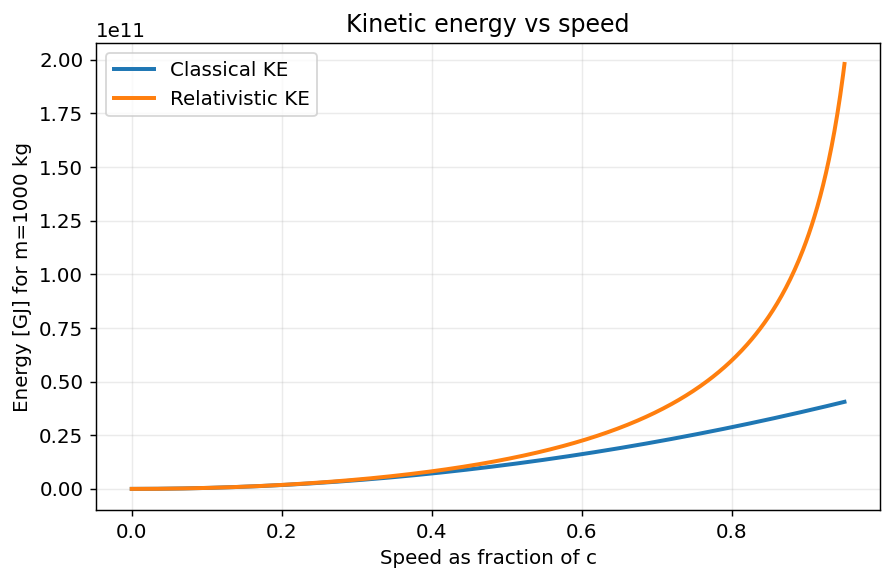

In [13]:
m_vehicle = 1000.0  # kg, arbitrary benchmark mass
v_frac = np.linspace(0.0, 0.95, 500)
v_vals = v_frac * C_PHYSICAL

gamma_v = 1.0 / np.sqrt(1.0 - v_frac ** 2)
E_class = 0.5 * m_vehicle * v_vals ** 2
E_rel = (gamma_v - 1.0) * m_vehicle * C_PHYSICAL ** 2

# Plot in GJ to keep scale readable
J_TO_GJ = 1e-9
fig, ax = plt.subplots()
ax.plot(v_frac, E_class * J_TO_GJ, label="Classical KE")
ax.plot(v_frac, E_rel * J_TO_GJ, label="Relativistic KE")
ax.set_xlabel("Speed as fraction of c")
ax.set_ylabel("Energy [GJ] for m=1000 kg")
ax.set_title("Kinetic energy vs speed")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


In [14]:
target_fracs = np.array([0.1, 0.3, 0.5, 0.9])
target_v = target_fracs * C_PHYSICAL

target_E_class = 0.5 * m_vehicle * target_v ** 2
target_gamma = 1.0 / np.sqrt(1.0 - target_fracs ** 2)
target_E_rel = (target_gamma - 1.0) * m_vehicle * C_PHYSICAL ** 2

energy_df = pd.DataFrame({
    "Speed": [f"{f:.1f}c" for f in target_fracs],
    "v [m/s]": target_v,
    "Classical KE [J]": target_E_class,
    "Relativistic KE [J]": target_E_rel,
    "Relativistic / Classical": target_E_rel / target_E_class,
})
energy_df


,Speed,v [m/s],Classical KE [J],Relativistic KE [J],Relativistic / Classical
0,0.1c,29979245.8,4.493776e+17,4.527763e+17,1.007563
1,0.3c,89937737.4,4.044398e+18,4.339625e+18,1.072996
2,0.5c,149896229.0,1.123444e+19,1.390379e+19,1.237604
3,0.9c,269813212.2,3.639958e+19,1.163131e+20,3.195450


### Brief interpretation
- At low speed, classical and relativistic energies are close.
- As $v\to c$, relativistic energy rises much faster than $\frac12 m v^2$.
- For futuristic transport concepts near relativistic speed, energy demand becomes a dominant bottleneck.
- In this notebook, those energetic trends motivate why a relativistic speed law modifies time-optimal geometry.


## 6) Discussion
- **Geometric trend:** relativistic trajectories are qualitatively less aggressive than the classical cycloid when relativistic effects are stronger (larger $g y_B / c^2$).
- **Why less deep/steep?** In the classical model, dropping deeper quickly gives large speed gains $v\sim\sqrt{y}$. In the relativistic model, speed gain saturates as $v<c$, so extra depth yields diminishing time benefit.
- **Model clarity:** this remains a simplified uniform-gravity + special-relativistic kinetic-energy model.
- **Future work:** variable gravity fields, spacetime curvature (GR), and realistic propulsion/control would be natural extensions.


## Poster-ready conclusions
- The classical brachistochrone between fixed endpoints is a cycloid and beats simple trial paths (line/parabola) in travel time.
- Replacing $v(y)=\sqrt{2gy}$ with a relativistic $v(y)$ preserves a similar variational framework but changes optimal geometry.
- Numerical integration of $dx/dy = v/\sqrt{k^2-v^2}$ with endpoint matching provides a practical way to generate relativistic trajectories.
- In the low-speed limit (physical $c$, lab scales), relativistic and classical results are nearly identical, as expected.
- In stronger effective relativistic regimes (larger $g y_B/c^2$), optimal curves become less aggressively deep and travel times increase.
- Energy scaling shows why near-$c$ transport is challenging: relativistic kinetic energy grows far faster than classical estimates.
